<a href="https://colab.research.google.com/github/ompandey0211/Image_Recognition_Project/blob/main/Image_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
print(tf.__version__)

2.20.0


In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving dataset.zip to dataset.zip


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'dataset.zip', 'dataset', 'image_classifier.keras', 'requirements.txt']


In [ ]:
import zipfile

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")


In [ ]:
train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_data = train.flow_from_directory(
    "/content/dataset/train",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

validation_data = train.flow_from_directory(
    "/content/dataset/train",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 16 images belonging to 2 classes.
Found 3 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer (reduces overfitting)
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os

print("Dataset:", os.listdir("/content/dataset"))
print("Train:", os.listdir("/content/dataset/train"))
print("Test:", os.listdir("/content/dataset/test"))
print("Cat images:", os.listdir("/content/dataset/train/cat")[:5])
print("Dog images:", os.listdir("/content/dataset/train/dog")[:5])

Dataset: ['train', 'test']
Train: ['dog', 'cat']
Test: ['dog', 'cat']
Cat images: ['cat.jpg.webp', 'CAT8.JPG.webp', 'cat5.jpg.jpg', 'cat6.jpg.jpg', 'CATA.JPG.webp']
Dog images: ['dog8.jpg.jpg', 'dog5.jpg.webp', 'dog8.jpg.webp', 'dog6.jpg.jpg', 'dog9.jpg.jpg']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    "/content/dataset/test",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

Found 19 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


In [ ]:
import os

print(os.listdir("/content/dataset"))
print(os.listdir("/content/dataset/train"))
print(os.listdir("/content/dataset/test"))

['train', 'test']
['dog', 'cat']
['dog', 'cat']


In [ ]:
import os

print("Train Cat Images:", len(os.listdir("/content/dataset/train/cat")))
print("Train Dog Images:", len(os.listdir("/content/dataset/train/dog")))
print("Test Cat Images:", len(os.listdir("/content/dataset/test/cat")))
print("Test Dog Images:", len(os.listdir("/content/dataset/test/dog")))

Train Cat Images: 19
Train Dog Images: 20
Test Cat Images: 8
Test Dog Images: 8


In [ ]:
print(os.listdir("/content/dataset/train/cat")[:10])
print(os.listdir("/content/dataset/train/dog")[:10])

['cat.jpg.webp', 'CAT8.JPG.webp', 'cat5.jpg.jpg', 'cat6.jpg.jpg', 'CATA.JPG.webp', 'cat5.jpg.webp', 'cat2.jpg.webp', 'cat7.jpg.jpg', 'CAT8.JPG.jpg', 'cat3.jpg.jpg']
['dog8.jpg.jpg', 'dog5.jpg.webp', 'dog8.jpg.webp', 'dog6.jpg.jpg', 'dog9.jpg.jpg', 'dog5.jpg.jpg', 'dog7.jpg.webp', 'dog6.jpg.webp', 'dog10.jpg.jpg', 'dog.jpg.webp']


In [ ]:
from PIL import Image

img = Image.open("/content/dataset/train/cat/cat.jpg.webp")
print(img.format)
print(img.size)

WEBP
(1059, 706)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

Found 19 images belonging to 2 classes.


In [ ]:
from PIL import Image
import os

folders = [
    "/content/dataset/train/cat",
    "/content/dataset/train/dog",
    "/content/dataset/test/cat",
    "/content/dataset/test/dog"
]

for folder in folders:
    for filename in os.listdir(folder):
        if filename.lower().endswith(".webp"):
            path = os.path.join(folder, filename)
            img = Image.open(path).convert("RGB")
            new_path = os.path.splitext(path)[0] + ".jpg"
            img.save(new_path, "JPEG")

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
train_data = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

Found 19 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(150,150),
    batch_size=4,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    "/content/dataset/test",
    target_size=(150,150),
    batch_size=4,
    class_mode="binary"
)

Found 19 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 605ms/step - accuracy: 0.4737 - loss: 0.9559 - val_accuracy: 0.5000 - val_loss: 0.7020
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5263 - loss: 0.8745 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4737 - loss: 0.6883 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5263 - loss: 0.6856 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7895 - loss: 0.6352 - val_accuracy: 0.5000 - val_loss: 0.7449
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6316 - loss: 0.5840 - val_accuracy: 0.5000 - val_loss: 0.7344
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7895 - loss: 0.5538 - val_accuracy: 0.5000 - val_loss: 0.7540
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7368 - loss: 0.4727 - val_accuracy: 0.5000 - val_loss: 0.9389

In [ ]:
print("Test Cats:", len(os.listdir("/content/dataset/test/cat")))
print("Test Dogs:", len(os.listdir("/content/dataset/test/dog")))

Test Cats: 8
Test Dogs: 8


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 583ms/step - accuracy: 0.5263 - loss: 0.9799 - val_accuracy: 0.5000 - val_loss: 1.0187
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5263 - loss: 0.7498 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5263 - loss: 0.6992 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5789 - loss: 0.6628 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8947 - loss: 0.5774 - val_accuracy: 0.5000 - val_loss: 0.8450
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5263 - loss: 0.9685 - val_accuracy: 0.5000 - val_loss: 0.7043
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7368 - loss: 0.6438 - val_accuracy: 0.5000 - val_loss: 0.7081
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6842 - loss: 0.6649 - val_accuracy: 0.3750 - val_loss: 0.7131

In [ ]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3750 - loss: 0.7294
Test Accuracy: 0.375


In [ ]:
model.save("image_classifier.keras")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 1000125816.jpg to 1000125816.jpg


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'dataset.zip', 'dataset', 'image_classifier.keras', '1000125816.jpg', 'requirements.txt']


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the uploaded image
img = image.load_img("/content/1000125816.jpg", target_size=(150,150))

# Convert to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Normalize pixel values
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

print("Prediction value:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("🐶 Dog")
else:
    print("🐱 Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
Prediction value: 0.69305617
🐶 Dog


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'dataset.zip', 'dataset', 'image_classifier.keras', '1000125816.jpg', 'requirements.txt']


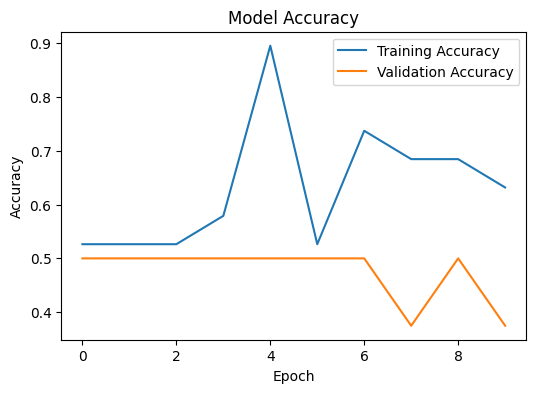

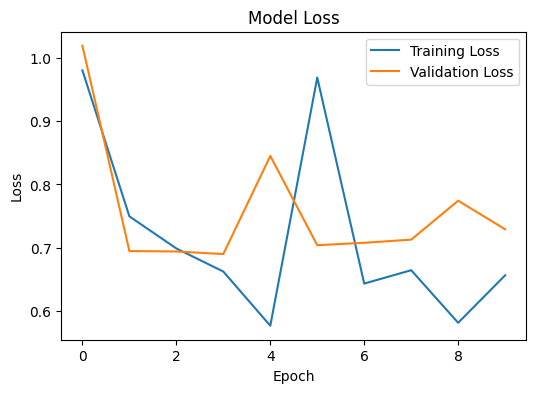

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
requirements = """
tensorflow
streamlit
numpy
matplotlib
Pillow
opencv-python
scikit-learn
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'dataset.zip', 'dataset', 'image_classifier.keras', '1000125816.jpg', 'requirements.txt']


In [ ]:
with open("requirements.txt", "r") as f:
    print(f.read())

tensorflow
streamlit
numpy
matplotlib
Pillow
opencv-python
scikit-learn


In [ ]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.listdir("/content"))


['.config', 'dataset', 'image_classifier.keras', 'requirements.txt']


In [ ]:
import os

file_path = "/content/image_classifier.keras"

if os.path.exists(file_path):
    size_bytes = os.path.getsize(file_path)
    size_mb = size_bytes / (1024 * 1024)

    print(f"File Name : {os.path.basename(file_path)}")
    print(f"File Size : {size_mb:.2f} MB")
else:
    print("File not found!")


File Name : image_classifier.keras
File Size : 55.30 MB


In [ ]:
from google.colab import files

files.download("/content/image_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>